<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
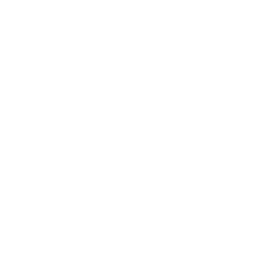
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Procesovervågning af stålvalseværk</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Multivariat SPC til tykkelses- og overfladekvalitetskontrol på varmvalseværk &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>


## Resumé

Et varmvalseværk ruller stålslabber til tynde coils. Otte korrelerede
procesignaler (tykkelser, valsekraft, valsegab, motorstrøm,
udgangstemperatur) bevæger sig sammen, når linjen kører normalt, så at
overvåge dem ét diagram ad gangen overser de fælles skift, der betyder
noget. Dette eksempel bygger en multivariat baseline med **PROC
MVPMODEL** og strømmer derefter 100 produktionscoils gennem
**PROC MVPMONITOR**, som scorer hver coil med en enkelt Hotellings
*T*&sup2;-statistik og sammenligner den med en kontrolgrænse.

Mod en in-control-grænse på *T*&sup2; = **17.13** (&alpha; = 0.05)
signalerer **4 ud af 100 coils** uden for kontrol — coils **91, 92, 94
og 95**, netop det vindue, hvor et chatter-udbrud fra backup-valsen
blev indsat. Den højeste *T*&sup2; når **21.91** ved coil 95, ca.
**1.3&times;** grænsen. Den gradvise valseslid-rampe over de senere
coils løfter baseline-*T*&sup2;, men forbliver under grænsen indtil
chatter-hændelsen, så diagrammet adskiller tydeligt langsom drift fra
den akutte fejl, der kræver øjeblikkelig opmærksomhed.


## Datakilder

- **mill_baseline** &mdash; 50 coils rullet i en kendt velfungerende
  periode af kampagnen; bruges til at tilpasse den multivariate
  (PCA) referencemodel.
- **mill_stream** &mdash; 100 coils fra den aktive linje. Coils 1&ndash;55
  kører i kontrol; valseslid udvikler sig gradvist over coils
  56&ndash;100; et chatter-udbrud fra backup-valsen rammer coils
  91&ndash;95.
- **Procesvariable** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> Miljøet kører ulicenseret, så datasæt er begrænset til 100
> observationer. Scenariet er tilpasset denne grænse: forstyrrelsen
> placeres sent i en strøm på 100 coils frem for ved coil 2.800 af 5.000.



---


### Trin 1 &mdash; Byg den multivariate referencemodel

`PROC MVPMODEL` udfører en principalkomponentanalyse af de seks
procesvariable på den in-control-baseline og skriver loadings,
egenværdier og centrering/skalering til `mill_model`. Tre komponenter
bevares. Denne model definerer, hvad "normalt" ser ud som en enkelt
multivariat region i stedet for seks uafhængige intervaller.



In [1]:
data mill_baseline;
  CALL streaminit(66);
  GØR coil_id = 1 TIL 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    UDDATA;
  SLUT;
KØR;

PROCEDURE mvpmodel data=mill_baseline outmodel=mill_model;
  VARIABEL entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  MÆRKAT entry_thickness="Indgangstykkelse (mm)" exit_thickness="Udgangstykkelse (mm)"
        rolling_force="Valsekraft (N)" roll_gap="Valsegab (mm)"
        motor_current="Motorstrøm (A)" exit_temp="Udgangstemperatur (grader C)";
  ncomp=3;
KØR;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         Indgangstykkelse (mm)Udgangstykkelse (mm)Valsekraft (N)Valsegab (mm)Motorstrøm (A)Udgangstemperatur (grader C)
  Indgangstykkelse (mm)    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  Udgangstykkelse (mm)   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  Valsekraft (N)   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  Valsegab (mm)   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  Motorstrøm (A)    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  Udgangstemperatur (grader C)    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284  


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---


### Trin 2 &mdash; Stream produktionscoils og score dem

`PROC MVPMONITOR` projicerer hver af de 100 produktionscoils på den
gemte model og beregner dens Hotellings *T*&sup2;. Proceduren udleder
kontrolgrænsen fra modellens dimensioner og standardværdien
&alpha; = 0.05, og markerer derefter enhver coil, hvis *T*&sup2;
overstiger den. Resultaterne, inklusive kolonnerne `_TSQUARED`,
`_LIMIT` og `_SIGNAL`, skrives til `mill_scores` med nøgle `coil_id`.



In [2]:
data mill_stream;
  CALL streaminit(42);
  GØR coil_id = 1 TIL 100;
    /* valseslid stiger fra 0 til 1 over coils 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* chatter-udbrud fra backup-valsen på coils 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    FJERN wear chatter;
    UDDATA;
  SLUT;
KØR;

PROCEDURE mvpmonitor data=mill_stream MODEL=mill_model
                out=mill_scores;
  VARIABEL entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
  MÆRKAT entry_thickness="Indgangstykkelse (mm)" exit_thickness="Udgangstykkelse (mm)"
        rolling_force="Valsekraft (N)" roll_gap="Valsegab (mm)"
        motor_current="Motorstrøm (A)" exit_temp="Udgangstemperatur (grader C)"
        coil_id="Coil-ID";
KØR;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4
  Variables Monitored: Indgangstykkelse (mm), Udgangstykkelse (mm), Valsekraft (N), Valsegab (mm), Motorstrøm (A), Udgangstemperatur (grader C)





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Procedureresuméet rapporterer kontrolgrænsen og antallet af
signaler. Nedenfor viser det udskrevne udsnit omkring forstyrrelsen, at
baseline-coils ligger godt under grænsen, mens chatter-vinduet driver
fire coils over den.



In [3]:
/* Marker coils uden for kontrol og gem alarm-T2 til plotning */
data mill_scores;
  SÆT mill_scores;
  MÆRKAT coil_id="Coil-ID" _TSQUARED="Hotellings T2" _LIMIT="Kontrolgrænse"
        _SIGNAL="Signal (0=i kontrol, 1=alarm)" t2_alarm="T2-alarm";
  HVIS _SIGNAL = 1 SÅ t2_alarm = _TSQUARED;
  ELLERS t2_alarm = .;
KØR;

PROCEDURE UDSKRIV data=mill_scores(firstobs=88 obs=96) noobs MÆRKAT;
  VARIABEL coil_id _TSQUARED _LIMIT _SIGNAL;
  TITEL 'T2-scorer i chatter-vinduet (coils 88-96)';
KØR;


                                       T2-scorer i chatter-vinduet (coils 88-96)                                        

Coil-ID  Hotellings T2   Kontrolgrænse  Signal (0=i kontrol, 1=alarm)
     88       9.983151       17.133408                              0
     89       2.915646       17.133408                              0
     90        7.80613       17.133408                              0
     91      18.813814       17.133408                              1
     92      18.249361       17.133408                              1
     93      16.638221       17.133408                              0
     94      17.981792       17.133408                              1
     95      21.912329       17.133408                              1
     96       5.118574       17.133408                              0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---


### Trin 3 &mdash; Multivariat kontroldiagram

Diagrammet lægger den per-coil *T*&sup2; oven på dens kontrolgrænse.
Coils uden for kontrol er fremhævet med rødt; den stiplede lodrette
markør angiver starten på chatter-udbruddet. Den langsomme stigning mod
højre er valseslid, der løfter baseline; de fire røde punkter er den
akutte chatter-fejl.



                                       T2-scorer i chatter-vinduet (coils 88-96)                                        




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


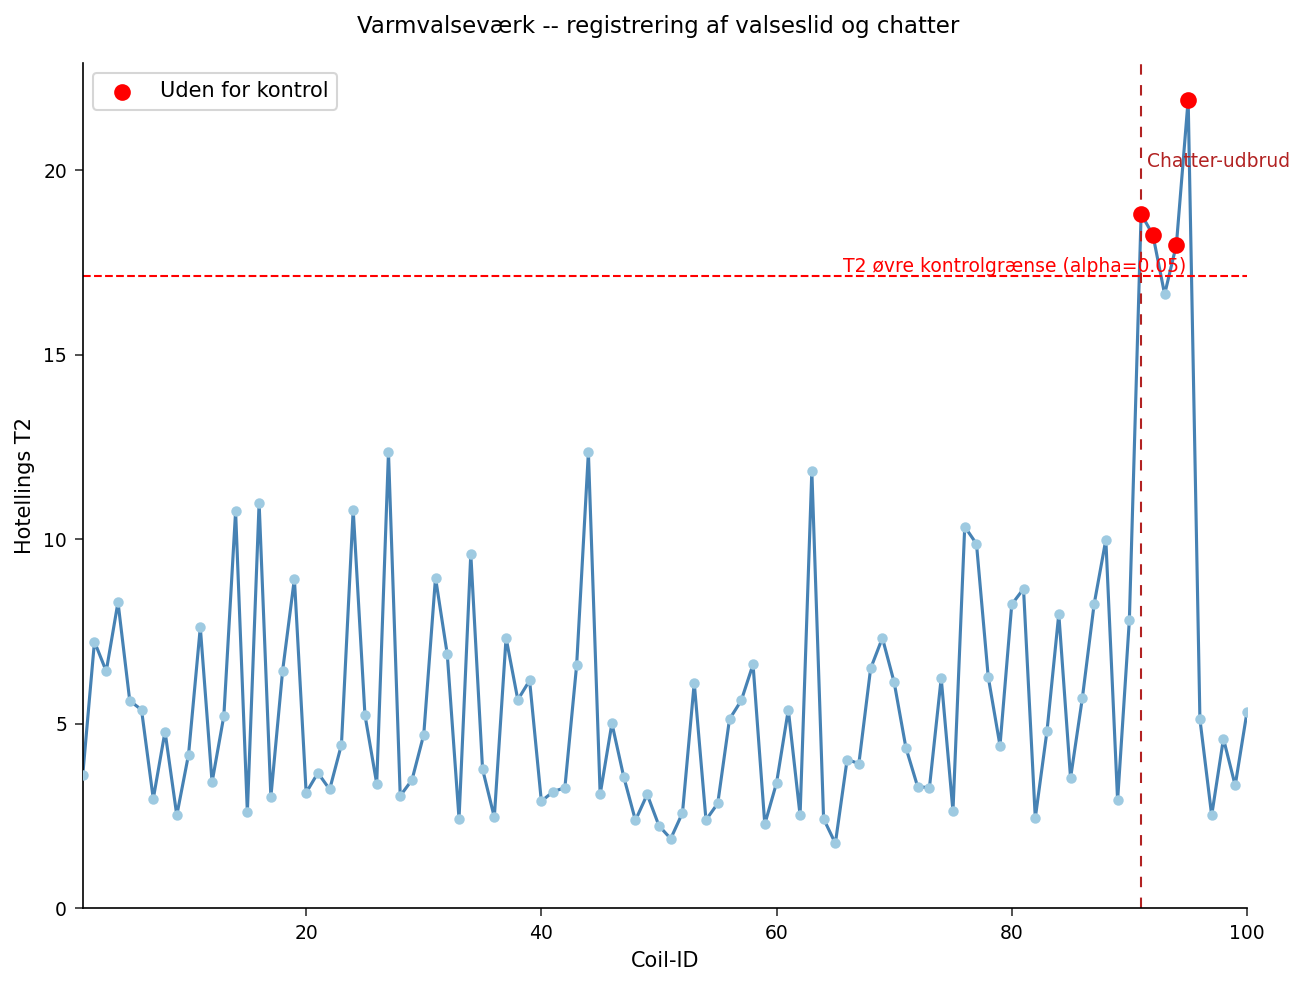

In [4]:
PROCEDURE SGPLOT data=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Uden for kontrol';
  REFLINE _LIMIT / AXIS=y
          MÆRKAT='T2 øvre kontrolgrænse (alpha=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x MÆRKAT='Chatter-udbrud'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS MÆRKAT='Coil-ID' MIN=1 MAX=100;
  YAXIS MÆRKAT="Hotellings T2" MIN=0;
  TITEL 'Varmvalseværk -- registrering af valseslid og chatter';
KØR;


---


### Trin 4 &mdash; Kvantificér coils uden for kontrol

Coils uden for kontrol sendes til et separat datasæt til
kvalitetsafdelingen. `PROC MEANS` sammenligner *T*&sup2;-niveauet for
de markerede coils med den in-control-population, og de markerede
coils eksporteres til downstream skrot-/omarbejdningsrouting.



In [5]:
data mill_ooc;
  SÆT mill_scores;
  HVIS _SIGNAL = 1;
KØR;

PROCEDURE GENNEMSNIT data=mill_scores n mean MAX maxdec=2;
  KLASSE _SIGNAL;
  VARIABEL _TSQUARED;
  TITEL 'T2 efter kontroltilstand (0 = i kontrol, 1 = signal)';
KØR;

PROCEDURE UDSKRIV data=mill_ooc noobs MÆRKAT;
  VARIABEL coil_id _TSQUARED _LIMIT;
  TITEL 'Coils uden for kontrol markeret til inspektion';
KØR;

PROCEDURE EKSPORTERE data=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
KØR;


                                  T2 efter kontroltilstand (0 = i kontrol, 1 = signal)                                  

                                                  The MEANS Procedure

                                      Analysis Variable : _TSQUARED Hotellings T2

        Signal (0=i kontrol, 1=alarm)          N Obs           Mean        Maximum
        --------------------------------------------------------------------------
        0                                         96           5.39          16.64
        1                                          4          19.24          21.91
        --------------------------------------------------------------------------

                                     Coils uden for kontrol markeret til inspektion                                     

Coil-ID  Hotellings T2   Kontrolgrænse
     91      18.813814       17.133408
     92      18.249361       17.133408
     94      17.981792       17.133408
     95      21.912329       1


NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Konklusioner

- **Overvågede coils**: 100; **kontrolgrænse** *T*&sup2; = **17.13**
  (&alpha; = 0.05).
- **Coils uden for kontrol**: **4** &mdash; coils **91, 92, 94, 95**, alle
  inden for det indsatte chatter-vindue (91&ndash;95). Coil 93 topper ved
  *T*&sup2; = 16.64, lige under grænsen.
- **Højeste alvorlighed**: *T*&sup2; = **21.91** ved coil 95 (ca. 1.3&times;
  grænsen); in-control-coils har i gennemsnit *T*&sup2; &asymp; **5.4**.
- **Slid vs. fejl**: den gradvise valseslid-rampe løfter baseline for de
  senere coils, men krydser aldrig grænsen alene, så det ene
  multivariate diagram adskiller langsom drift (overvåg) fra den akutte
  chatter-hændelse (handl).
- **Handling**: de fire markerede coils eksporteres til
  `steel_mill_ooc_coils.csv` til inspektion og skrot-/omarbejdningsrouting;
  chatter-signaturen peger på backup-valsens leje som noget, der bør
  inspiceres inden næste kampagne.



---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>

